# Lesson 3: Reflection and Blogpost Writing

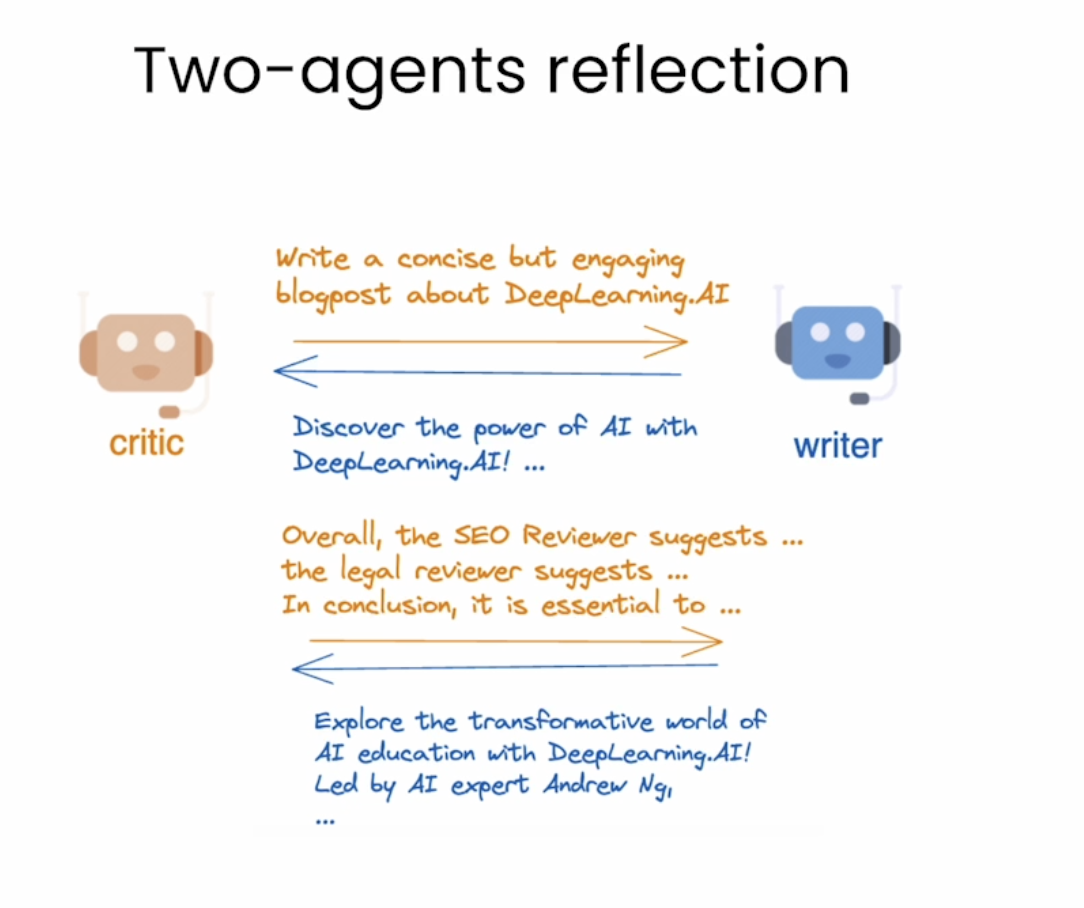

## Setup

In [16]:
llm_config = {"model": "gpt-3.5-turbo"}

## The task!

In [17]:
task = '''
        Write a concise but engaging blogpost about
       DeepLearning.AI. Make sure the blogpost is
       within 100 words.
       '''


## Create a writer agent

In [18]:
import autogen

writer = autogen.AssistantAgent(
    name="Writer",
    system_message="You are a writer. You write engaging and concise " 
        "blogpost (with title) on given topics. You must polish your "
        "writing based on the feedback you receive and give a refined "
        "version. Only return your final work without additional comments.",
    llm_config=llm_config,
)

In [19]:
reply = writer.generate_reply(messages=[{"content": task, "role": "user"}])

In [20]:
print(reply)

Title: Unveiling the Power of DeepLearning.AI

Delve into the revolutionary world of DeepLearning.AI, a cutting-edge platform transforming industries worldwide. With accessible courses curated by AI expert Andrew Ng, this educational hub demystifies complex AI concepts and guides learners on a journey to mastering deep learning. From computer vision to natural language processing, DeepLearning.AI equips enthusiasts with the skills to innovate and excel in the AI realm. Join the community driving technological advancements and unleash your potential with DeepLearning.AI. Elevate your expertise, broaden your horizons, and embrace the future of artificial intelligence today.


## Adding reflection 

Create a critic agent to reflect on the work of the writer agent.

In [21]:
critic = autogen.AssistantAgent(
    name="Critic",
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    llm_config=llm_config,
    system_message="You are a critic. You review the work of "
                "the writer and provide constructive "
                "feedback to help improve the quality of the content.",
)

In [22]:
res = critic.initiate_chat(
    recipient=writer,
    message=task,
    max_turns=2,
    summary_method="last_msg"
)

Critic (to Writer):


        Write a concise but engaging blogpost about
       DeepLearning.AI. Make sure the blogpost is
       within 100 words.
       

--------------------------------------------------------------------------------
Writer (to Critic):

Title: Unveiling the Power of DeepLearning.AI

Delve into the revolutionary world of DeepLearning.AI, a cutting-edge platform transforming industries worldwide. With accessible courses curated by AI expert Andrew Ng, this educational hub demystifies complex AI concepts and guides learners on a journey to mastering deep learning. From computer vision to natural language processing, DeepLearning.AI equips enthusiasts with the skills to innovate and excel in the AI realm. Join the community driving technological advancements and unleash your potential with DeepLearning.AI. Elevate your expertise, broaden your horizons, and embrace the future of artificial intelligence today.

----------------------------------------------------------

## Nested chat

In [23]:
SEO_reviewer = autogen.AssistantAgent(
    name="SEO Reviewer",
    llm_config=llm_config,
    system_message="You are an SEO reviewer, known for "
        "your ability to optimize content for search engines, "
        "ensuring that it ranks well and attracts organic traffic. " 
        "Make sure your suggestion is concise (within 3 bullet points), "
        "concrete and to the point. "
        "Begin the review by stating your role.",
)


In [24]:
legal_reviewer = autogen.AssistantAgent(
    name="Legal Reviewer",
    llm_config=llm_config,
    system_message="You are a legal reviewer, known for "
        "your ability to ensure that content is legally compliant "
        "and free from any potential legal issues. "
        "Make sure your suggestion is concise (within 3 bullet points), "
        "concrete and to the point. "
        "Begin the review by stating your role.",
)

In [25]:
ethics_reviewer = autogen.AssistantAgent(
    name="Ethics Reviewer",
    llm_config=llm_config,
    system_message="You are an ethics reviewer, known for "
        "your ability to ensure that content is ethically sound "
        "and free from any potential ethical issues. " 
        "Make sure your suggestion is concise (within 3 bullet points), "
        "concrete and to the point. "
        "Begin the review by stating your role. ",
)

In [26]:
# It will aggregate reviews from all the reviewers.
meta_reviewer = autogen.AssistantAgent(
    name="Meta Reviewer",
    llm_config=llm_config,
    system_message="You are a meta reviewer, you aggragate and review "
    "the work of other reviewers and give a final suggestion on the content.",
)

## Orchestrate the nested chats to solve the task

In [27]:
def reflection_message(recipient, messages, sender, config):
    return f'''Review the following content. 
            \n\n {recipient.chat_messages_for_summary(sender)[-1]['content']}'''

# Here, we have 4 chats and each one has a recipient as a reviewer.
# Laters we will register these chats with the critic agent and it will be used as a sender by default.
# So, we don't need to mention critic agent in every chat.
# summary of first 3 chats will be passed to 4th chat.


# reflection_message: We also needs to provide the text to review.
# The comman way to provide the content by using summary of previous conversation to the first reviewer chat agent.
# 
review_chats = [
    {
     "recipient": SEO_reviewer, 
     "message": reflection_message, 
     "summary_method": "reflection_with_llm",
     "summary_args": {"summary_prompt" : 
        "Return review into as JSON object only:"
        "{'Reviewer': '', 'Review': ''}. Here Reviewer should be your role",},
     "max_turns": 1},
    {
    "recipient": legal_reviewer, "message": reflection_message, 
     "summary_method": "reflection_with_llm",
     "summary_args": {"summary_prompt" : 
        "Return review into as JSON object only:"
        "{'Reviewer': '', 'Review': ''}.",},
     "max_turns": 1},
    {"recipient": ethics_reviewer, "message": reflection_message, 
     "summary_method": "reflection_with_llm",
     "summary_args": {"summary_prompt" : 
        "Return review into as JSON object only:"
        "{'reviewer': '', 'review': ''}",},
     "max_turns": 1},
     {"recipient": meta_reviewer, 
      "message": "Aggregrate feedback from all reviewers and give final suggestions on the writing.", 
     "max_turns": 1},
]


In [28]:

critic.register_nested_chats(
    review_chats,
    trigger=writer,
)

**Note**: You might get a slightly different response than what's shown in the video. Feel free to try different task.

In [29]:
res = critic.initiate_chat(
    recipient=writer,
    message=task,
    max_turns=2,
    summary_method="last_msg"
)

Critic (to Writer):


        Write a concise but engaging blogpost about
       DeepLearning.AI. Make sure the blogpost is
       within 100 words.
       

--------------------------------------------------------------------------------
Writer (to Critic):

Title: Unveiling the Power of DeepLearning.AI

Delve into the revolutionary world of DeepLearning.AI, a cutting-edge platform transforming industries worldwide. With accessible courses curated by AI expert Andrew Ng, this educational hub demystifies complex AI concepts and guides learners on a journey to mastering deep learning. From computer vision to natural language processing, DeepLearning.AI equips enthusiasts with the skills to innovate and excel in the AI realm. Join the community driving technological advancements and unleash your potential with DeepLearning.AI. Elevate your expertise, broaden your horizons, and embrace the future of artificial intelligence today.

----------------------------------------------------------


--------------------------------------------------------------------------------
Meta Reviewer (to Critic):

After aggregating feedback from all reviewers, it is clear that there are key points that need to be addressed in the writing:

1. Incorporate industry-specific terms related to deep learning and artificial intelligence to enhance search visibility.
2. Include relevant keywords in meta tags for improved search engine indexing.
3. Utilize internal linking to connect relevant pages within the website for improved SEO and user experience.
4. Ensure compliance with laws regarding educational claims and avoid unsubstantiated statements about mastering AI or guaranteeing career outcomes.
5. Avoid using potentially misleading language such as "revolutionary" and "cutting-edge" without clear evidence.
6. Confirm that representations about the platform align with the actual content and features offered to prevent deceptive advertising claims.
7. Maintain transparency and honesty in repr

## Get the summary

In [30]:
print(res.summary)

Title: Navigating DeepLearning.AI: A Comprehensive Overview

Embark on a transformative journey with DeepLearning.AI, a leading platform in the dynamic field of artificial intelligence. Curated by renowned AI expert Andrew Ng, the platform provides comprehensive courses in key areas like computer vision and natural language processing. By mastering these advanced concepts, learners can amplify their skills and contribute to groundbreaking innovations in AI technology. Join a thriving community of enthusiasts dedicated to pushing the boundaries of what's possible in AI. Elevate your expertise and unlock new opportunities with DeepLearning.AI today.
